# K-Means Clustering — Reddit Trend Dataset

## 1. Install Dependencies

In [ ]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn plotly umap-learn tqdm

## 2. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import umap
import re
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print('All libraries imported!')

All libraries imported!


## 3. Load Dataset

In [31]:
# Load the Reddit CSV
df = pd.read_csv('final_trendingtopics_reddit.csv')

print(f'Dataset: {len(df):,} posts')
print(f'Columns: {list(df.columns)}')
print(f'\nNiches: {df["niche"].unique()}')
df.head()

Dataset: 7,090 posts
Columns: ['post_id', 'niche', 'title', 'author', 'score', 'upvote_ratio', 'num_comments', 'timestamp_utc', 'permalink', 'url', 'selftext', 'full_text', 'text_translated']

Niches: <StringArray>
['worldnews', 'technology', 'gaming', 'science', 'movies', 'smartphones']
Length: 6, dtype: str


,post_id,niche,title,author,score,upvote_ratio,num_comments,timestamp_utc,permalink,url,selftext,full_text,text_translated
0,1sn1h85,worldnews,Pope: World is being ravaged by a handful of t...,TheTelegraph,76659,0.96,2214,2026-04-16 12:02:28,https://reddit.com/r/worldnews/comments/1sn1h8...,https://www.telegraph.co.uk/world-news/2026/04...,NaN,Pope: World is being ravaged by a handful of t...,Pope: World is being ravaged by a handful of t...
1,1s56i0f,worldnews,FBI Director Kash Patel’s Personal Inbox Breac...,nicevillager,72090,0.97,3305,2026-03-27 14:58:13,https://reddit.com/r/worldnews/comments/1s56i0...,https://indianexpress.com/article/world/us-new...,NaN,FBI Director Kash Patel’s Personal Inbox Breac...,FBI Director Kash Patel’s Personal Inbox Breac...
2,1skp97a,technology,Man Who Threw Molotov Cocktail At Sam Altman’s...,Amentet,68149,0.91,757,2026-04-13 21:50:09,https://reddit.com/r/technology/comments/1skp9...,https://theonion.com/man-who-threw-molotov-coc...,NaN,Man Who Threw Molotov Cocktail At Sam Altman’s...,Man Who Threw Molotov Cocktail At Sam Altman’s...
3,1smfq4p,technology,"Ticketmaster is an illegal monopoly, jury rule...",MarvelsGrantMan136,59637,0.98,1091,2026-04-15 19:10:11,https://reddit.com/r/technology/comments/1smfq...,https://www.theverge.com/policy/912689/live-na...,NaN,"Ticketmaster is an illegal monopoly, jury rule...","Ticketmaster is an illegal monopoly, jury rule..."
4,1sey6ua,worldnews,Iran cuts all diplomatic channels with US ahea...,Geo_NL,52006,0.96,3509,2026-04-07 14:50:25,https://reddit.com/r/worldnews/comments/1sey6u...,https://www.firstpost.com/world/iran-cuts-all-...,NaN,Iran cuts all diplomatic channels with US ahea...,Iran cuts all diplomatic channels with US ahea...


## 4. Dataset Overview

In [32]:
# Posts per niche
niche_counts = df['niche'].value_counts()

print('Post Distribution by Niche:\n')
for niche, count in niche_counts.items():
    pct = count / len(df) * 100
    print(f'  r/{niche}: {count:,} ({pct:.1f}%)')

# Basic engagement stats
print(f'\nEngagement Stats:')
print(f'  Avg score       : {df["score"].mean():.1f}')
print(f'  Avg upvote ratio: {df["upvote_ratio"].mean():.2f}')
print(f'  Avg comments    : {df["num_comments"].mean():.1f}')
print(f'  Unique authors  : {df["author"].nunique():,}')
print(f'  Date range      : {df["timestamp_utc"].min()} → {df["timestamp_utc"].max()}')

Post Distribution by Niche:

  r/movies: 1,588 (22.4%)
  r/worldnews: 1,518 (21.4%)
  r/technology: 1,417 (20.0%)
  r/smartphones: 1,226 (17.3%)
  r/gaming: 818 (11.5%)
  r/science: 523 (7.4%)

Engagement Stats:
  Avg score       : 1582.0
  Avg upvote ratio: 0.78
  Avg comments    : 163.4
  Unique authors  : 3,664
  Date range      : 2026-03-25 08:56:14 → 2026-04-24 08:27:30


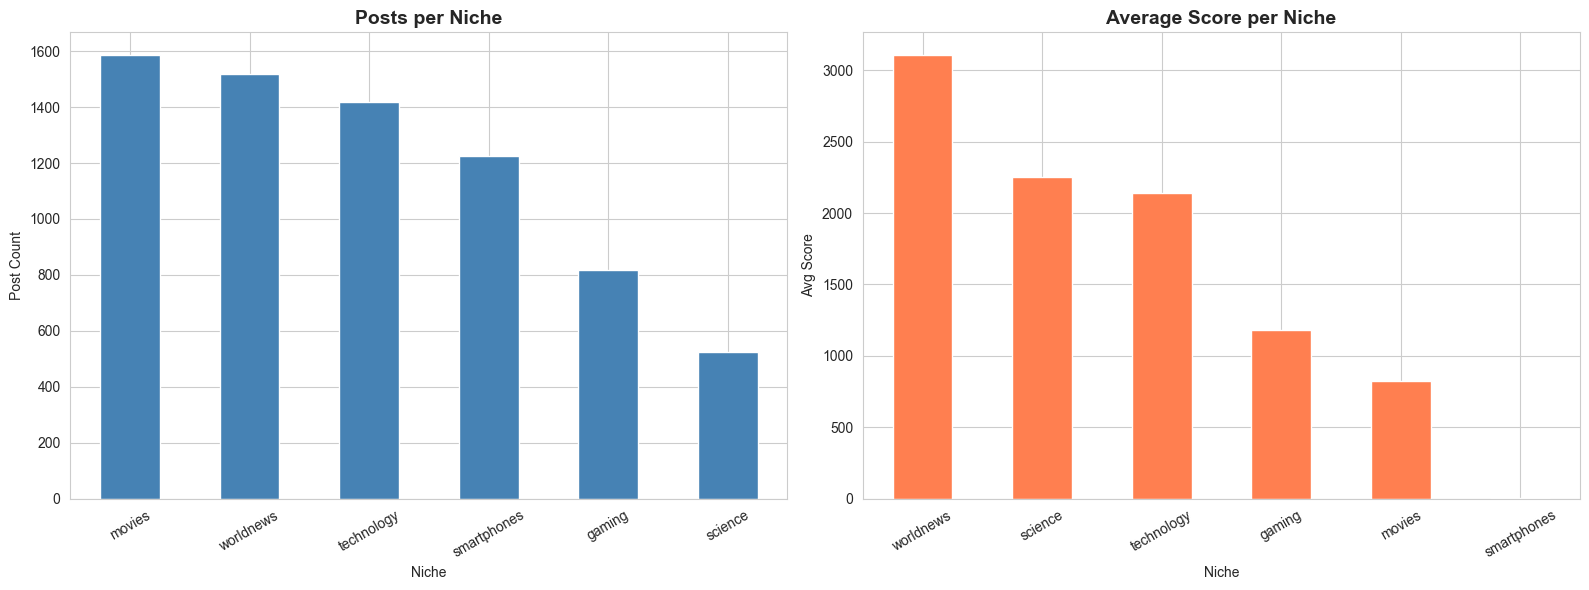

In [33]:
# Posts per niche bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Post count
niche_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Posts per Niche', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Niche')
axes[0].set_ylabel('Post Count')
axes[0].tick_params(axis='x', rotation=30)

# Average score per niche
avg_score = df.groupby('niche')['score'].mean().sort_values(ascending=False)
avg_score.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Score per Niche', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Niche')
axes[1].set_ylabel('Avg Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Prepare Text for Embedding

We use `text_translated` — translations of `full_text` (title + selftext) — so the model handles all languages uniformly.

In [35]:
# Drop rows with missing text_translated
df = df.dropna(subset=['text_translated']).reset_index(drop=True)

# Remove empty strings
df = df[df['text_translated'].str.strip() != ''].reset_index(drop=True)

print(f'Posts available for embedding: {len(df):,}')
print(f'\nSample text_translated values:')
for i, text in enumerate(df['text_translated'].head(3)):
    print(f'  [{i+1}] {str(text)[:120]}...')

Posts available for embedding: 7,090

Sample text_translated values:
  [1] Pope: World is being ravaged by a handful of tyrants...
  [2] FBI Director Kash Patel’s Personal Inbox Breached: Iranian Hackers Leak Private Photos and Resume...
  [3] Man Who Threw Molotov Cocktail At Sam Altman’s Home Claims He Was Following ChatGPT Recipe For Risotto...


## 6. Generate Embeddings (Hugging Face Model)

In [36]:
MODEL_NAME = 'all-MiniLM-L6-v2'

print(f'Loading model: {MODEL_NAME}')
print('First run will download the model...\n')

model = SentenceTransformer(MODEL_NAME)

print(f'Model loaded!')
print(f'Embedding dimensions: {model.get_sentence_embedding_dimension()}')
print(f'Max sequence length : {model.max_seq_length} tokens')

Loading model: all-MiniLM-L6-v2
First run will download the model...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
Embedding dimensions: 384
Max sequence length : 256 tokens


In [37]:
# Generate embeddings from text_translated
print(f'Generating embeddings for {len(df):,} posts...')
print('This may take a few minutes...\n')

texts = df['text_translated'].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f'\nEmbeddings generated!')
print(f'Shape: {embeddings.shape}')
print(f'   • {embeddings.shape[0]:,} posts')
print(f'   • {embeddings.shape[1]} dimensions each')

np.save('reddit_embeddings.npy', embeddings)
print('\nSaved to reddit_embeddings.npy')

Generating embeddings for 7,090 posts...
This may take a few minutes...



Batches:   0%|          | 0/222 [00:00<?, ?it/s]


Embeddings generated!
Shape: (7090, 384)
   • 7,090 posts
   • 384 dimensions each

Saved to reddit_embeddings.npy


In [38]:
# Quick similarity sanity check
sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
print(f'Sample similarity check:')
print(f'\nPost 1: {texts[0][:120]}')
print(f'Post 2: {texts[1][:120]}')
print(f'\nCosine similarity: {sim:.4f}')
print(f'Interpretation: {sim:.2f} → {"similar" if sim > 0.5 else "different"} content')

Sample similarity check:

Post 1: Pope: World is being ravaged by a handful of tyrants
Post 2: FBI Director Kash Patel’s Personal Inbox Breached: Iranian Hackers Leak Private Photos and Resume

Cosine similarity: 0.0671
Interpretation: 0.07 → different content


## 7. Find Optimal K (Elbow + Silhouette)

In [39]:
K_range = range(2, 21)  # Test K = 2 to 20

inertias              = []
silhouette_scores     = []
davies_bouldin_scores = []

print('Testing different K values...')
print('This will take a few minutes...\n')

for k in tqdm(K_range, desc='Testing K'):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings, labels))
    davies_bouldin_scores.append(davies_bouldin_score(embeddings, labels))

print('\nAnalysis complete!')

Testing different K values...
This will take a few minutes...



Testing K: 100%|██████████| 19/19 [00:40<00:00,  2.12s/it]


Analysis complete!


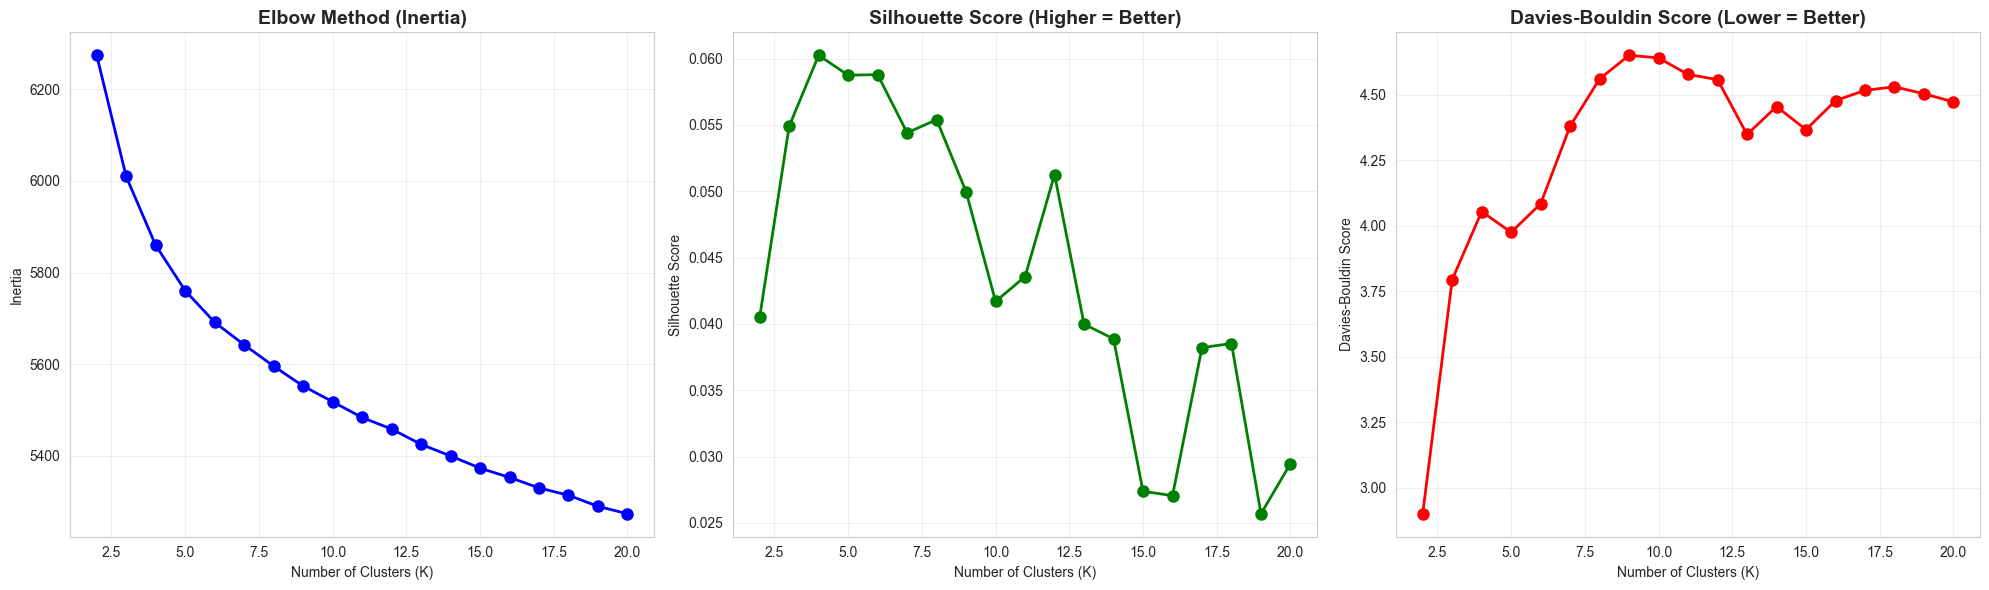


K  | Inertia     | Silhouette | Davies-Bouldin
-------------------------------------------------------
 2 |      6273.8 |     0.0405 | 2.8999
 3 |      6009.4 |     0.0549 | 3.7943
 4 |      5859.5 |     0.0603 | 4.0547
 5 |      5760.6 |     0.0587 | 3.9755
 6 |      5691.5 |     0.0588 | 4.0845
 7 |      5642.4 |     0.0544 | 4.3808
 8 |      5595.9 |     0.0554 | 4.5616
 9 |      5552.5 |     0.0500 | 4.6518
10 |      5518.2 |     0.0417 | 4.6416
11 |      5483.9 |     0.0436 | 4.5785
12 |      5458.6 |     0.0513 | 4.5588
13 |      5425.3 |     0.0400 | 4.3491
14 |      5400.0 |     0.0389 | 4.4558
15 |      5373.4 |     0.0274 | 4.3676
16 |      5353.1 |     0.0271 | 4.4786
17 |      5330.3 |     0.0382 | 4.5179
18 |      5314.3 |     0.0385 | 4.5314
19 |      5290.1 |     0.0257 | 4.5048
20 |      5273.8 |     0.0295 | 4.4738

✅ Best K by Silhouette  : 4
✅ Best K by Davies-Bouldin: 2


In [40]:
# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

k_list = list(K_range)

# Elbow
axes[0].plot(k_list, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(k_list, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (Higher = Better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin
axes[2].plot(k_list, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score (Lower = Better)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reddit_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print scores table
print('\nK  | Inertia     | Silhouette | Davies-Bouldin')
print('-' * 55)
for i, k in enumerate(k_list):
    print(f'{k:2d} | {inertias[i]:11.1f} | {silhouette_scores[i]:10.4f} | {davies_bouldin_scores[i]:.4f}')

best_sil_k = k_list[silhouette_scores.index(max(silhouette_scores))]
best_db_k  = k_list[davies_bouldin_scores.index(min(davies_bouldin_scores))]
print(f'\n✅ Best K by Silhouette  : {best_sil_k}')
print(f'✅ Best K by Davies-Bouldin: {best_db_k}')

In [41]:
# ✏️ Set your chosen K here based on the plots above
OPTIMAL_K = 6

print(f'Using K = {OPTIMAL_K} clusters')

Using K = 6 clusters


## 8. Apply K-Means with Optimal K

In [43]:
print(f'Fitting KMeans with K={OPTIMAL_K}...')

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embeddings)

df['cluster'] = cluster_labels

# Metrics
sil  = silhouette_score(embeddings, cluster_labels)
db   = davies_bouldin_score(embeddings, cluster_labels)
ch   = calinski_harabasz_score(embeddings, cluster_labels)

print(f'\n📊 Final Clustering Metrics (K={OPTIMAL_K}):')
print(f'   Silhouette Score     : {sil:.4f}  (higher is better, range: -1 to 1)')
print(f'   Davies-Bouldin Score : {db:.4f}  (lower is better)')
print(f'   Calinski-Harabasz    : {ch:.1f}  (higher is better)')

print(f'\n📋 Posts per cluster:')
for c in range(OPTIMAL_K):
    count = (cluster_labels == c).sum()
    print(f'   Cluster {c}: {count:,} posts ({count/len(df)*100:.1f}%)')

Fitting KMeans with K=6...

📊 Final Clustering Metrics (K=6):
   Silhouette Score     : 0.0588  (higher is better, range: -1 to 1)
   Davies-Bouldin Score : 4.0845  (lower is better)
   Calinski-Harabasz    : 231.8  (higher is better)

📋 Posts per cluster:
   Cluster 0: 2,107 posts (29.7%)
   Cluster 1: 1,486 posts (21.0%)
   Cluster 2: 1,140 posts (16.1%)
   Cluster 3: 1,081 posts (15.2%)
   Cluster 4: 523 posts (7.4%)
   Cluster 5: 753 posts (10.6%)


## 9. Dimensionality Reduction & Visualization

In [44]:
# PCA to 50 dims first for speed, then UMAP to 2D
print('Running PCA (384 → 50 dims)...')
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)
print(f'Variance explained: {pca.explained_variance_ratio_.sum():.1%}')

print('\nRunning UMAP (50 → 2 dims)...')
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_umap = reducer.fit_transform(embeddings_pca)
print('UMAP complete!')

np.save('embeddings_pca.npy', embeddings_pca)
np.save('embeddings_umap.npy', embeddings_umap)

Running PCA (384 → 50 dims)...
Variance explained: 52.5%

Running UMAP (50 → 2 dims)...
UMAP complete!


In [45]:
# UMAP coloured by cluster
umap_df = pd.DataFrame({
    'x'       : embeddings_umap[:, 0],
    'y'       : embeddings_umap[:, 1],
    'cluster' : df['cluster'].astype(str),
    'niche'   : df['niche'],
    'title'   : df['title'].str[:80],
    'score'   : df['score']
})

fig = px.scatter(
    umap_df,
    x='x', y='y',
    color='cluster',
    hover_data=['niche', 'title', 'score'],
    title=f'UMAP — Reddit Posts by Cluster (K={OPTIMAL_K})',
    width=900, height=650
)
fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.show()

In [46]:
# UMAP coloured by niche
fig2 = px.scatter(
    umap_df,
    x='x', y='y',
    color='niche',
    hover_data=['cluster', 'title', 'score'],
    title=f'UMAP — Reddit Posts by Niche (K={OPTIMAL_K})',
    width=900, height=650
)
fig2.update_traces(marker=dict(size=4, opacity=0.7))
fig2.show()

## 10. Cluster vs Niche Heatmap

📊 CLUSTER vs NICHE Distribution:

niche    gaming  movies  science  smartphones  technology  worldnews
cluster                                                             
0            94     100      490          144         844        435
1            45    1435        0            1           5          0
2             2       5        4            0          60       1069
3             1       0        0         1074           6          0
4             6      13       25            3         462         14
5           670      35        4            4          40          0



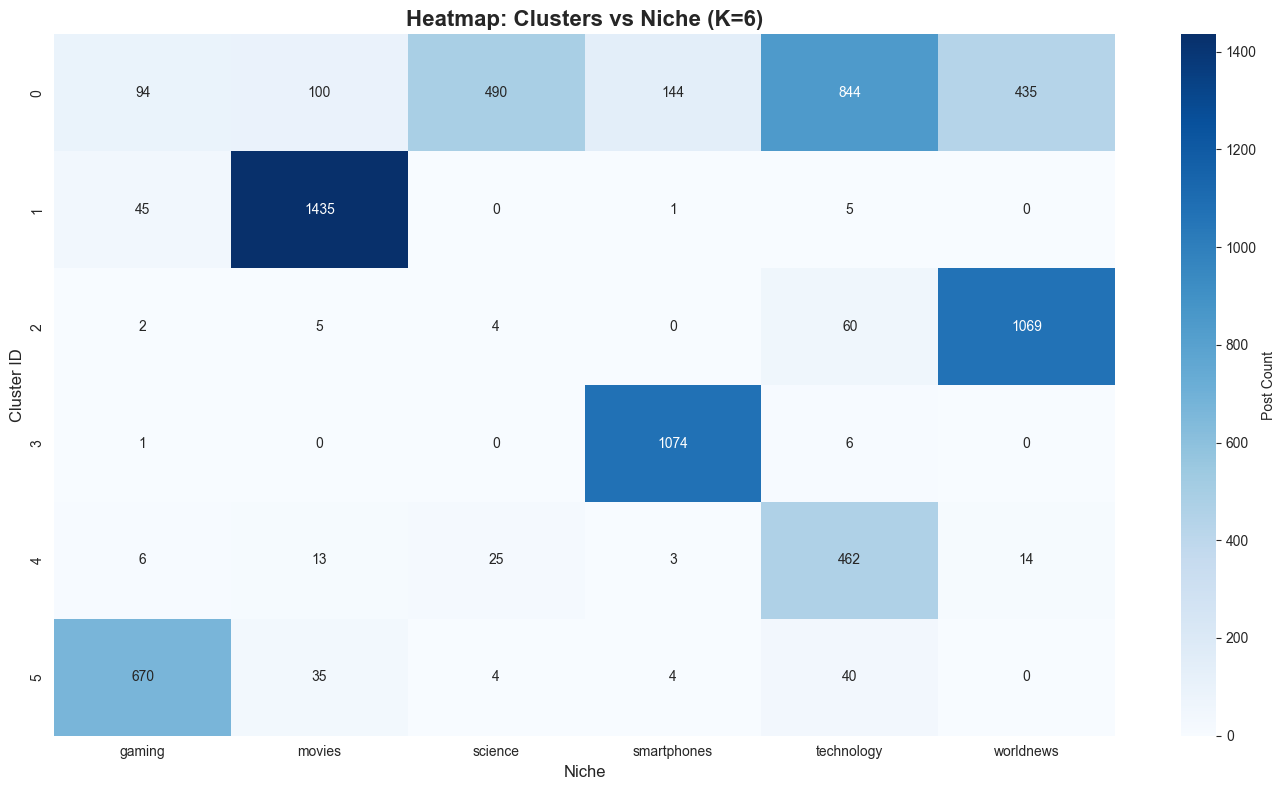


💡 Diagonal dominance = clusters align well with niches
💡 Mixed clusters = cross-niche topics (good for trend discovery!)


In [47]:
# Cross-tabulation: Clusters vs Niche
cluster_niche_matrix = pd.crosstab(df['cluster'], df['niche'])

print('📊 CLUSTER vs NICHE Distribution:\n')
print(cluster_niche_matrix)
print('\n' + '='*80)

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_niche_matrix,
    annot=True, fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'Post Count'}
)
plt.title(f'Heatmap: Clusters vs Niche (K={OPTIMAL_K})', fontsize=16, fontweight='bold')
plt.xlabel('Niche', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.savefig('reddit_cluster_niche_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Diagonal dominance = clusters align well with niches')
print('💡 Mixed clusters = cross-niche topics (good for trend discovery!)')

## 11. Sample Posts from Each Cluster

In [48]:
print('='*80)
print('SAMPLE POSTS FROM EACH CLUSTER')
print('='*80)

for cluster_id in range(OPTIMAL_K):
    cluster_posts = df[df['cluster'] == cluster_id]

    print(f'\n{"="*80}')
    print(f'🔹 CLUSTER {cluster_id} ({len(cluster_posts):,} posts)')
    print(f'{"="*80}')

    # Niche distribution
    niche_dist = cluster_posts['niche'].value_counts()
    print(f'\nNiche distribution:')
    for niche, count in niche_dist.items():
        print(f'  • r/{niche}: {count} ({count/len(cluster_posts)*100:.1f}%)')

    # Engagement stats
    print(f'\nEngagement:')
    print(f'  Avg score        : {cluster_posts["score"].mean():.0f}')
    print(f'  Avg upvote ratio : {cluster_posts["upvote_ratio"].mean():.2f}')
    print(f'  Avg comments     : {cluster_posts["num_comments"].mean():.0f}')

    # 5 sample posts
    samples = cluster_posts.sample(min(5, len(cluster_posts)), random_state=42)
    print(f'\nSample posts:')
    for i, (idx, row) in enumerate(samples.iterrows(), 1):
        print(f'{i}. [r/{row["niche"]}] ⬆️  {row["score"]:,}')
        print(f'   {str(row["title"])[:150]}...')
        print()

print('='*80)
print('\nCan you identify themes in each cluster?')

SAMPLE POSTS FROM EACH CLUSTER

🔹 CLUSTER 0 (2,107 posts)

Niche distribution:
  • r/technology: 844 (40.1%)
  • r/science: 490 (23.3%)
  • r/worldnews: 435 (20.6%)
  • r/smartphones: 144 (6.8%)
  • r/movies: 100 (4.7%)
  • r/gaming: 94 (4.5%)

Engagement:
  Avg score        : 2076
  Avg upvote ratio : 0.85
  Avg comments     : 147

Sample posts:
1. [r/science] ⬆️  707
   Physical inactivity is linked to ~500,000 deaths annually in the U.S., a 2026 study reports. Researchers found low activity levels significantly incre...

2. [r/technology] ⬆️  25
   Anthropic's Project Glasswing CVE count is still guesswork...

3. [r/technology] ⬆️  4,571
   The Feds Say Cutting Fuel With Ethanol Will Bring Down Gas Prices. We're Not Buying It...

4. [r/science] ⬆️  1,491
   Researchers find DMT provides longer-lasting antidepressant effects than S-ketamine in mice study. Findings highlight the promise of psychedelic compo...

5. [r/worldnews] ⬆️  1,399
   Saab dangles sovereign data centre in Montre

## 12. Keyword Extraction per Cluster

In [49]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def extract_keywords(texts, top_n=10):
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        words = [
            w for w in words
            if w not in ENGLISH_STOP_WORDS
            and len(w) > 3
            and not w.startswith(('http', '@', '#', 'www'))
            and w.isalpha()  # letters only, no punctuation/numbers
        ]
        all_words.extend(words)
    word_freq = Counter(all_words)
    return word_freq.most_common(top_n)


print('📊 TOP KEYWORDS PER CLUSTER\n')
print('='*80)

for cluster_id in range(OPTIMAL_K):
    posts     = df[df['cluster'] == cluster_id]['text_translated'].tolist()
    keywords  = extract_keywords(posts, top_n=10)
    niches    = df[df['cluster'] == cluster_id]['niche'].value_counts().index.tolist()

    print(f'\nCluster {cluster_id} ({len(posts):,} posts) — dominant niches: {", ".join(["r/"+n for n in niches[:3]])}')
    kw_list = [f'{word}({count})' for word, count in keywords]
    print(f'   {', '.join(kw_list)}')

print('\n' + '='*80)
print('\nThese are frequency-based keywords from text_translated')

📊 TOP KEYWORDS PER CLUSTER


Cluster 0 (2,107 posts) — dominant niches: r/technology, r/science, r/worldnews
   phone(130), study(114), just(108), people(98), data(95), says(88), like(82), social(66), time(64), screen(59)

Cluster 1 (1,486 posts) — dominant niches: r/movies, r/gaming, r/technology
   movie(1134), like(863), just(796), movies(694), film(574), think(370), really(358), know(287), good(281), time(268)

Cluster 2 (1,140 posts) — dominant niches: r/worldnews, r/technology, r/movies
   iran(362), says(222), trump(132), hormuz(112), ukraine(112), strait(104), russian(98), talks(72), iranian(70), russia(67)

Cluster 3 (1,081 posts) — dominant niches: r/smartphones, r/technology, r/gaming
   phone(1459), iphone(730), like(657), just(546), good(536), samsung(519), battery(483), want(436), camera(435), looking(360)

Cluster 4 (523 posts) — dominant niches: r/technology, r/science, r/worldnews
   says(46), tech(28), anthropic(28), billion(27), data(25), meta(23), model(23), people(

## 13. Top Posts per Cluster (by Score)

In [50]:
print('🏆 TOP 3 POSTS PER CLUSTER (by score)\n')
print('='*80)

for cluster_id in range(OPTIMAL_K):
    top_posts = (
        df[df['cluster'] == cluster_id]
        .sort_values('score', ascending=False)
        .head(3)
    )

    print(f'\n🔹 CLUSTER {cluster_id}')
    for i, (idx, row) in enumerate(top_posts.iterrows(), 1):
        print(f'  {i}. [r/{row["niche"]}] Score: {row["score"]:,}  |  Comments: {row["num_comments"]:,}')
        print(f'     {str(row["title"])[:140]}')
        print(f'     {row["permalink"]}')
        print()

print('='*80)

🏆 TOP 3 POSTS PER CLUSTER (by score)


🔹 CLUSTER 0
  1. [r/worldnews] Score: 76,659  |  Comments: 2,214
     Pope: World is being ravaged by a handful of tyrants
     https://reddit.com/r/worldnews/comments/1sn1h85/pope_world_is_being_ravaged_by_a_handful_of/

  2. [r/technology] Score: 68,149  |  Comments: 757
     Man Who Threw Molotov Cocktail At Sam Altman’s Home Claims He Was Following ChatGPT Recipe For Risotto
     https://reddit.com/r/technology/comments/1skp97a/man_who_threw_molotov_cocktail_at_sam_altmans/

  3. [r/technology] Score: 59,637  |  Comments: 1,091
     Ticketmaster is an illegal monopoly, jury rules / This verdict is the first step toward a potential breakup of Live Nation-Ticketmaster.
     https://reddit.com/r/technology/comments/1smfq4p/ticketmaster_is_an_illegal_monopoly_jury_rules/


🔹 CLUSTER 1
  1. [r/technology] Score: 33,775  |  Comments: 1,600
     AI Model &amp; ‘MAGA’ Influencer Emily Hart Unmasked as Indian Man
     https://reddit.com/r/technology/co

## 14. Save All Results

In [51]:
# Save main dataframe with cluster labels
df.to_csv('reddit_with_clusters.csv', index=False)
print('Saved: reddit_with_clusters.csv')

# Save embeddings
np.save('reddit_embeddings.npy', embeddings)
print('Saved: reddit_embeddings.npy')

np.save('cluster_labels.npy', cluster_labels)
print('Saved: cluster_labels.npy')

np.save('embeddings_pca.npy', embeddings_pca)
np.save('embeddings_umap.npy', embeddings_umap)
print('Saved: embeddings_pca.npy and embeddings_umap.npy')

print(f'\n✅ All results saved! Total posts: {len(df):,} across {OPTIMAL_K} clusters')

Saved: reddit_with_clusters.csv
Saved: reddit_embeddings.npy
Saved: cluster_labels.npy
Saved: embeddings_pca.npy and embeddings_umap.npy

✅ All results saved! Total posts: 7,090 across 6 clusters


---
# 🔬 PER-NICHE EXPERIMENTATION
The cells below let you run the full KMeans pipeline on a **single niche** in isolation.
This gives cleaner, more focused clusters compared to running on the entire dataset.

**How to use:**
1. Run Section 15 once — it loads the full dataframe and model (skip if already loaded above)
2. Go to Section 16, set `NICHE` to whichever subreddit you want to study
3. Run Section 16 onwards — everything auto-adjusts to that niche
4. To switch niche, just change `NICHE` in Section 16 and re-run from there

## 15. Reload Data & Model (skip if already loaded above)

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
from tqdm import tqdm
import umap
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Load full dataset
df_full = pd.read_csv('final_trendingtopics_reddit.csv')
df_full = df_full.dropna(subset=['text_translated']).reset_index(drop=True)
df_full = df_full[df_full['text_translated'].str.strip() != ''].reset_index(drop=True)

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f'✅ Full dataset loaded: {len(df_full):,} posts')
print(f'Available niches: {sorted(df_full["niche"].unique().tolist())}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Full dataset loaded: 7,090 posts
Available niches: ['gaming', 'movies', 'science', 'smartphones', 'technology', 'worldnews']


## 16. ✏️ Select Your Niche

In [54]:
# ============================================================
# ✏️  CHANGE THIS to experiment with different niches
# Options: 'technology', 'worldnews', 'science', 'gaming', 'movies', smartphones
NICHE = 'technology'
# ============================================================

# Filter dataset to selected niche
df_niche = df_full[df_full['niche'] == NICHE].reset_index(drop=True)

print(f'🎯 Selected niche : r/{NICHE}')
print(f'📊 Posts available: {len(df_niche):,}')
print(f'📅 Date range     : {df_niche["timestamp_utc"].min()} → {df_niche["timestamp_utc"].max()}')
print(f'⬆️  Avg score      : {df_niche["score"].mean():.1f}')
print(f'💬 Avg comments   : {df_niche["num_comments"].mean():.1f}')
print(f'👍 Avg upvote ratio: {df_niche["upvote_ratio"].mean():.2f}')

🎯 Selected niche : r/technology
📊 Posts available: 1,417
📅 Date range     : 2026-03-25 08:56:14 → 2026-04-24 08:19:06
⬆️  Avg score      : 2140.1
💬 Avg comments   : 161.6
👍 Avg upvote ratio: 0.80


## 17. Generate Niche Embeddings

In [55]:
print(f'Generating embeddings for r/{NICHE} ({len(df_niche):,} posts)...\n')

niche_texts      = df_niche['text_translated'].tolist()
niche_embeddings = model.encode(
    niche_texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f'\n✅ Embeddings shape: {niche_embeddings.shape}')

Generating embeddings for r/technology (1,417 posts)...



Batches:   0%|          | 0/45 [00:00<?, ?it/s]


✅ Embeddings shape: (1417, 384)


## 18. Find Optimal K for This Niche

In [56]:
K_range = range(2, 16)  # Test K = 2 to 15 (smaller range for single niche)

niche_inertias   = []
niche_silhouette = []
niche_db         = []

print(f'Testing K values for r/{NICHE}...\n')

for k in tqdm(K_range, desc='Testing K'):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(niche_embeddings)
    niche_inertias.append(km.inertia_)
    niche_silhouette.append(silhouette_score(niche_embeddings, labels))
    niche_db.append(davies_bouldin_score(niche_embeddings, labels))

print('Done!')

Testing K values for r/technology...



Testing K: 100%|██████████| 14/14 [00:04<00:00,  3.11it/s]

Done!


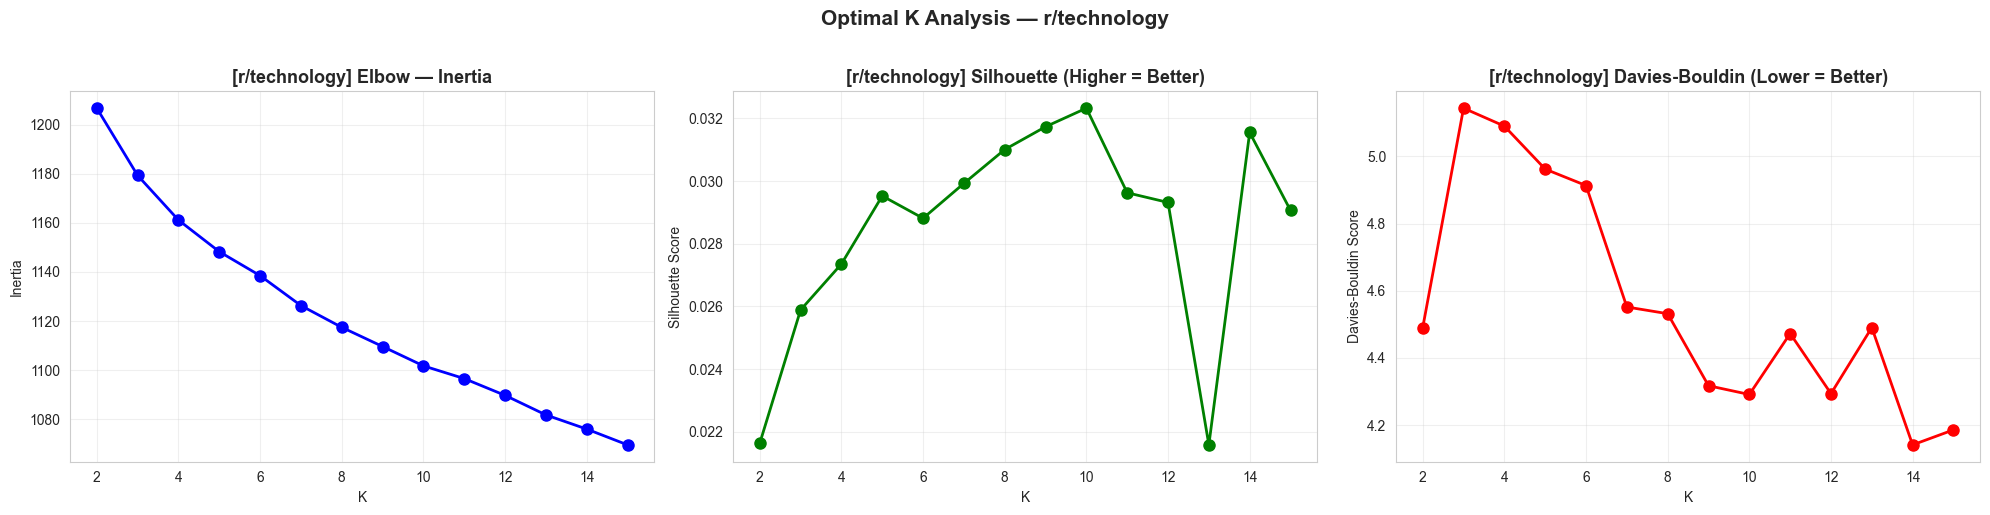

✅ Best K by Silhouette   : 10
✅ Best K by Davies-Bouldin: 14


In [57]:
# Plot Elbow + Silhouette for this niche
k_list = list(K_range)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(k_list, niche_inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title(f'[r/{NICHE}] Elbow — Inertia', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_list, niche_silhouette, 'go-', linewidth=2, markersize=8)
axes[1].set_title(f'[r/{NICHE}] Silhouette (Higher = Better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_list, niche_db, 'ro-', linewidth=2, markersize=8)
axes[2].set_title(f'[r/{NICHE}] Davies-Bouldin (Lower = Better)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Optimal K Analysis — r/{NICHE}', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{NICHE}_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

best_sil_k = k_list[niche_silhouette.index(max(niche_silhouette))]
best_db_k  = k_list[niche_db.index(min(niche_db))]
print(f'✅ Best K by Silhouette   : {best_sil_k}')
print(f'✅ Best K by Davies-Bouldin: {best_db_k}')

## 19. ✏️ Set K and Apply KMeans

In [58]:
# ============================================================
# ✏️  Set your chosen K based on the plots above
NICHE_K = 10
# ============================================================

km_niche            = KMeans(n_clusters=NICHE_K, random_state=42, n_init=10)
niche_cluster_labels = km_niche.fit_predict(niche_embeddings)
df_niche             = df_niche.copy()
df_niche['cluster']  = niche_cluster_labels

# Metrics
sil = silhouette_score(niche_embeddings, niche_cluster_labels)
db  = davies_bouldin_score(niche_embeddings, niche_cluster_labels)
ch  = calinski_harabasz_score(niche_embeddings, niche_cluster_labels)

print(f'📊 KMeans Results — r/{NICHE} (K={NICHE_K})')
print(f'   Silhouette Score     : {sil:.4f}')
print(f'   Davies-Bouldin Score : {db:.4f}')
print(f'   Calinski-Harabasz    : {ch:.1f}')
print(f'\n📋 Posts per cluster:')
for c in range(NICHE_K):
    count = (niche_cluster_labels == c).sum()
    print(f'   Cluster {c}: {count:,} posts ({count/len(df_niche)*100:.1f}%)')

📊 KMeans Results — r/technology (K=10)
   Silhouette Score     : 0.0323
   Davies-Bouldin Score : 4.2909
   Calinski-Harabasz    : 21.3

📋 Posts per cluster:
   Cluster 0: 121 posts (8.5%)
   Cluster 1: 118 posts (8.3%)
   Cluster 2: 121 posts (8.5%)
   Cluster 3: 95 posts (6.7%)
   Cluster 4: 175 posts (12.4%)
   Cluster 5: 125 posts (8.8%)
   Cluster 6: 60 posts (4.2%)
   Cluster 7: 129 posts (9.1%)
   Cluster 8: 291 posts (20.5%)
   Cluster 9: 182 posts (12.8%)


## 20. UMAP Visualization for This Niche

In [59]:
# PCA → UMAP
n_components_pca = min(50, niche_embeddings.shape[0] - 1, niche_embeddings.shape[1])

print(f'Running PCA (→ {n_components_pca} dims)...')
pca_niche          = PCA(n_components=n_components_pca, random_state=42)
niche_emb_pca      = pca_niche.fit_transform(niche_embeddings)

print(f'Running UMAP (→ 2 dims)...')
reducer_niche      = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
niche_emb_umap     = reducer_niche.fit_transform(niche_emb_pca)

# Interactive scatter plot
umap_niche_df = pd.DataFrame({
    'x'       : niche_emb_umap[:, 0],
    'y'       : niche_emb_umap[:, 1],
    'cluster' : df_niche['cluster'].astype(str),
    'title'   : df_niche['title'].str[:80],
    'score'   : df_niche['score'],
    'comments': df_niche['num_comments']
})

fig = px.scatter(
    umap_niche_df,
    x='x', y='y',
    color='cluster',
    hover_data=['title', 'score', 'comments'],
    title=f'UMAP — r/{NICHE} Clusters (K={NICHE_K})',
    width=900, height=650
)
fig.update_traces(marker=dict(size=5, opacity=0.75))
fig.show()

Running PCA (→ 50 dims)...
Running UMAP (→ 2 dims)...


## 21. Sample Posts from Each Niche Cluster

In [60]:
print('='*80)
print(f'SAMPLE POSTS — r/{NICHE} (K={NICHE_K})')
print('='*80)

for cluster_id in range(NICHE_K):
    cluster_posts = df_niche[df_niche['cluster'] == cluster_id]

    print(f'\n{"="*80}')
    print(f'🔹 CLUSTER {cluster_id} ({len(cluster_posts):,} posts)')
    print(f'{"="*80}')
    print(f'  Avg score        : {cluster_posts["score"].mean():.0f}')
    print(f'  Avg upvote ratio : {cluster_posts["upvote_ratio"].mean():.2f}')
    print(f'  Avg comments     : {cluster_posts["num_comments"].mean():.0f}')

    samples = cluster_posts.sample(min(5, len(cluster_posts)), random_state=42)
    print(f'\n  Sample posts:')
    for i, (idx, row) in enumerate(samples.iterrows(), 1):
        print(f'  {i}. ⬆️  {row["score"]:,}  |  💬 {row["num_comments"]:,}')
        print(f'     {str(row["title"])[:150]}')
        print()

print('='*80)

SAMPLE POSTS — r/technology (K=10)

🔹 CLUSTER 0 (121 posts)
  Avg score        : 3641
  Avg upvote ratio : 0.86
  Avg comments     : 127

  Sample posts:
  1. ⬆️  1,140  |  💬 62
     'Outrageous mess': About 2,000 AI road safety camera fines withdrawn in WA

  2. ⬆️  995  |  💬 54
     Journalist Rob Levine Sues FAA Over Drone No Fly Zone Designed to Prevent Filming ICE | A Minnesota photojournalist is challenging a 3,000 foot restri

  3. ⬆️  21,985  |  💬 1,361
     'No on-site doctor': Dental student died in ICU overseen by remote 'tele-health' physician who pronounced him dead on a video screen, lawsuit says…

  4. ⬆️  614  |  💬 85
     Mamdani Lifts NYC TikTok Ban for City Employees, but with Some Unusual Restrictions

  5. ⬆️  3,116  |  💬 258
     The US government wants Reddit to snitch on one of its users through a grand jury


🔹 CLUSTER 1 (118 posts)
  Avg score        : 3615
  Avg upvote ratio : 0.86
  Avg comments     : 227

  Sample posts:
  1. ⬆️  375  |  💬 36
     Dutch cen

## 22. Top Keywords per Niche Cluster

In [61]:
def extract_keywords(texts, top_n=10):
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        words = [
            w for w in words
            if w not in ENGLISH_STOP_WORDS
            and len(w) > 3
            and not w.startswith(('http', '@', '#', 'www'))
            and w.isalpha()
        ]
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)


print(f'📊 TOP KEYWORDS PER CLUSTER — r/{NICHE}\n')
print('='*80)

for cluster_id in range(NICHE_K):
    posts    = df_niche[df_niche['cluster'] == cluster_id]['text_translated'].tolist()
    keywords = extract_keywords(posts, top_n=12)
    kw_list  = [f'{w}({c})' for w, c in keywords]
    print(f'\nCluster {cluster_id} ({len(posts):,} posts):')
    print(f'   {', '.join(kw_list)}')

print('\n' + '='*80)

📊 TOP KEYWORDS PER CLUSTER — r/technology


Cluster 0 (121 posts):
   meta(19), court(15), social(9), media(9), lawsuit(7), addiction(7), glasses(7), chatgpt(6), jury(6), says(6), facial(6), rules(5)

Cluster 1 (118 posts):
   data(30), centers(14), tech(12), center(12), iran(10), internet(10), china(8), says(7), google(6), starlink(6), power(6), half(5)

Cluster 2 (121 posts):
   tesla(14), solar(12), energy(12), power(12), battery(12), fuel(9), electric(9), china(8), chinese(6), prices(6), batteries(6), charging(6)

Cluster 3 (95 posts):
   claude(18), code(17), data(10), anthropic(9), source(8), hackers(7), says(7), security(7), iran(6), signal(6), messages(6), used(6)

Cluster 4 (175 posts):
   scientists(14), human(13), artemis(12), moon(10), robots(9), claude(8), says(8), robot(8), space(7), smart(7), humanoid(7), world(6)

Cluster 5 (125 posts):
   microsoft(40), windows(29), apple(17), says(10), linux(9), games(8), game(8), copilot(7), xbox(7), tech(7), pass(6), palantir(5)

Cl

## 23. Top Posts per Niche Cluster (by Score)

In [62]:
print(f'🏆 TOP 3 POSTS PER CLUSTER — r/{NICHE}\n')
print('='*80)

for cluster_id in range(NICHE_K):
    top_posts = (
        df_niche[df_niche['cluster'] == cluster_id]
        .sort_values('score', ascending=False)
        .head(3)
    )
    print(f'\n🔹 CLUSTER {cluster_id}')
    for i, (idx, row) in enumerate(top_posts.iterrows(), 1):
        print(f'  {i}. Score: {row["score"]:,}  |  Comments: {row["num_comments"]:,}  |  Upvote ratio: {row["upvote_ratio"]:.2f}')
        print(f'     {str(row["title"])[:140]}')
        print(f'     {row["permalink"]}')
        print()

print('='*80)

🏆 TOP 3 POSTS PER CLUSTER — r/technology


🔹 CLUSTER 0
  1. Score: 68,149  |  Comments: 757  |  Upvote ratio: 0.91
     Man Who Threw Molotov Cocktail At Sam Altman’s Home Claims He Was Following ChatGPT Recipe For Risotto
     https://reddit.com/r/technology/comments/1skp97a/man_who_threw_molotov_cocktail_at_sam_altmans/

  2. Score: 59,637  |  Comments: 1,091  |  Upvote ratio: 0.98
     Ticketmaster is an illegal monopoly, jury rules / This verdict is the first step toward a potential breakup of Live Nation-Ticketmaster.
     https://reddit.com/r/technology/comments/1smfq4p/ticketmaster_is_an_illegal_monopoly_jury_rules/

  3. Score: 32,913  |  Comments: 573  |  Upvote ratio: 0.97
     Judge tosses lawsuit against companies who stopped advertising on X
     https://reddit.com/r/technology/comments/1s4fp9t/judge_tosses_lawsuit_against_companies_who/


🔹 CLUSTER 1
  1. Score: 30,857  |  Comments: 1,059  |  Upvote ratio: 0.95
     Bernie Sanders and AOC introduce bill to pause building 

## 24. Save Niche Results

In [63]:
# Save niche-specific outputs — filenames auto-include the niche name
df_niche.to_csv(f'{NICHE}_with_clusters.csv', index=False)
print(f'Saved: {NICHE}_with_clusters.csv')

np.save(f'{NICHE}_embeddings.npy', niche_embeddings)
print(f'Saved: {NICHE}_embeddings.npy')

np.save(f'{NICHE}_cluster_labels.npy', niche_cluster_labels)
print(f'Saved: {NICHE}_cluster_labels.npy')

np.save(f'{NICHE}_embeddings_umap.npy', niche_emb_umap)
print(f'Saved: {NICHE}_embeddings_umap.npy')

print(f'\n✅ r/{NICHE} done! {len(df_niche):,} posts across {NICHE_K} clusters')
print(f'\n💡 To experiment with another niche, go back to Section 16,')
print(f'   change NICHE = "gaming" (or any other), and re-run from there.')

Saved: technology_with_clusters.csv
Saved: technology_embeddings.npy
Saved: technology_cluster_labels.npy
Saved: technology_embeddings_umap.npy

✅ r/technology done! 1,417 posts across 10 clusters

💡 To experiment with another niche, go back to Section 16,
   change NICHE = "gaming" (or any other), and re-run from there.
